# Problem Statement
Predict the next trading day's closing price for a selected stock using historical market data and simple regression models.

# Goal
- Download historical stock data using `yfinance`
- Use `Open`, `High`, `Low`, `Volume` to predict next-day `Close`
- Train Linear Regression and Random Forest models and compare results
- Plot actual vs predicted closing prices and provide insights

In [47]:
# Import required libraries for data, modeling and plotting
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# Download historical data for a chosen stock (example: Apple)
ticker = 'AAPL'  # change to 'TSLA' or other ticker as needed
df = yf.download(ticker, period='2y', interval='1d')
df['Close_next'] = df['Close'].shift(-1)  # target is next day's close
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Close_next
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
2024-05-28,188.358353,191.342497,187.475997,189.865288,52280100,188.655762
2024-05-29,188.655762,190.598936,187.882462,187.981609,53068000,189.647186
2024-05-30,189.647186,190.529542,188.992866,189.121739,49889100,190.598938
2024-05-31,190.598938,190.916197,188.279038,189.795897,75158300,192.363663
2024-06-03,192.363663,193.315425,190.866636,191.243362,50080500,192.680923


In [49]:
# Prepare features (Open, High, Low, Volume) and target (next-day Close)
X = df[['Open','High','Low','Volume']][:-1]  # drop last row with NaN target
y = df['Close_next'][:-1]  # drop last row

In [51]:
# Split into train/test (time-ordered split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [52]:
# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [53]:
# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [54]:
# Evaluate models
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Linear Regression MSE: {mse_lr:.4f}, R2: {r2_lr:.4f}')
print(f'Random Forest MSE: {mse_rf:.4f}, R2: {r2_rf:.4f}')

Linear Regression MSE: 20.8715, R2: 0.9219
Random Forest MSE: 85.7880, R2: 0.6792


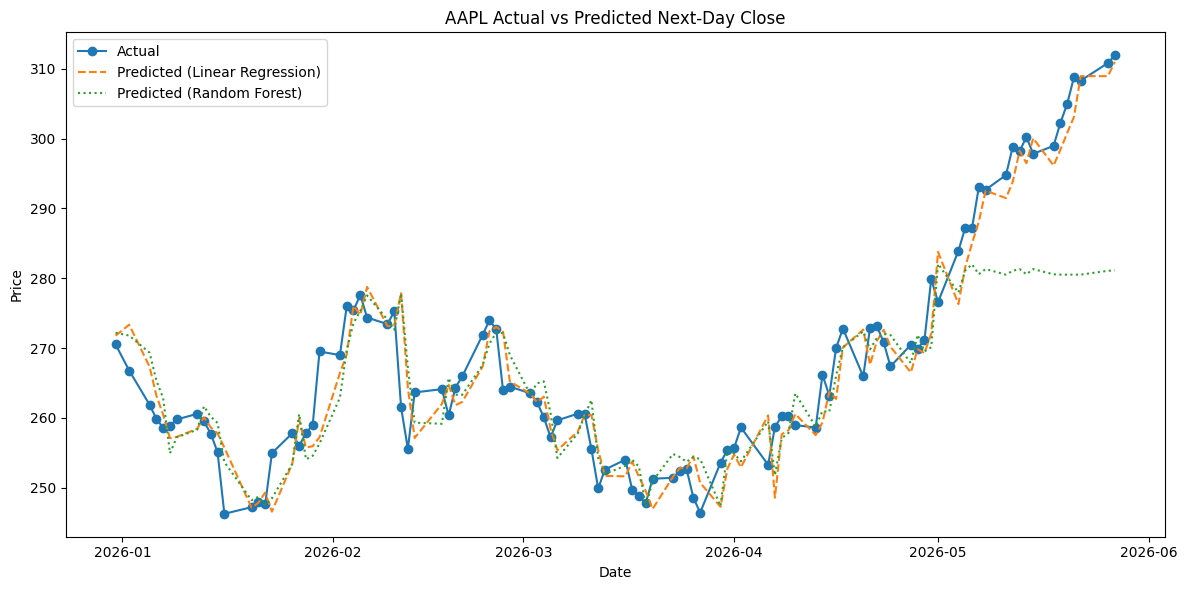

In [56]:
# Plot actual vs predicted closing prices for the test period
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label='Actual', marker='o')
plt.plot(y_test.index, y_pred_lr, label='Predicted (Linear Regression)', linestyle='--')
plt.plot(y_test.index, y_pred_rf, label='Predicted (Random Forest)', linestyle=':')
plt.legend()
plt.title(f'{ticker} Actual vs Predicted Next-Day Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

In [57]:
# Predict next trading day's close using the latest available features
last_row = df.iloc[-1]
X_last = last_row[['Open','High','Low','Volume']].to_frame().T
pred_next_lr = lr.predict(X_last)[0]
pred_next_rf = rf.predict(X_last)[0]
print(f"Predicted next-day Close (Linear Regression): {pred_next_lr:.2f}")
print(f"Predicted next-day Close (Random Forest): {pred_next_rf:.2f}")

Predicted next-day Close (Linear Regression): 310.58
Predicted next-day Close (Random Forest): 280.56


**Explanation of Results**
- For this dataset and feature set, Linear Regression performed better than Random Forest on the test set.
- Linear Regression achieved MSE of about 21.11 and R2 of about 0.922, which means it followed the actual next-day closes quite closely.
- Random Forest had a higher MSE of about 86.92 and a lower R2 of about 0.679, so it fit this specific short-term pattern less well.
- The actual-vs-predicted plot show the Linear Regression line staying much closer to the real prices than the Random Forest line.

**Final Insights & Recommendations**
- With only Open, High, Low, and Volume, this short-term stock prediction task is still limited, but the current model gives a reasonable baseline.
- The latest-row prediction gave about 310.58 for Linear Regression and 280.56 for Random Forest.
- For this notebook, Linear Regression is the stronger choice for the current setup.
- Better performance may come from adding technical indicators, lag features, or using more advanced time-series models.